# VM Behavioural Clustering

Load and preserve the source data before feature engineering or cleaning.

In [19]:
%pip install matplotlib seaborn scikit-learn plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ---------------------------------------  9.7/9.9 MB 36.9 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 36.9 MB/s eta 0:00:01
   ---------------------------------------  9.7/9.9 MB 36.9 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 8.3 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [20]:
# Reproducible notebook setup
from pathlib import Path
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 100)

In [21]:
# Load source tables
DATA_DIR = Path.cwd()

vm_info = pd.read_csv(DATA_DIR / 'vm_info.csv')
vm_utilization = pd.read_csv(DATA_DIR / 'vm_utilization_timeseries.csv')
cpu_type_definitions = pd.read_csv(DATA_DIR / 'cpu_type_definitions.csv')
memory_type_definitions = pd.read_csv(DATA_DIR / 'memory_type_definitions.csv')

# Immutable-in-practice backups: retain these unchanged throughout cleaning and analysis.
vm_info_raw = vm_info.copy(deep=True)
vm_utilization_raw = vm_utilization.copy(deep=True)

print(f'VM metadata: {vm_info.shape[0]:,} rows × {vm_info.shape[1]} columns')
print(f'Utilization readings: {vm_utilization.shape[0]:,} rows × {vm_utilization.shape[1]} columns')

VM metadata: 1,500 rows × 8 columns
Utilization readings: 765,189 rows × 8 columns


In [22]:
# Standardize the two same-structured size lookup tables and stack them into one reference table.
cpu_reference = (
    cpu_type_definitions
    .rename(columns={'core_count_bucket': 'size_bucket'})
    .assign(resource_type='cpu')
)
memory_reference = (
    memory_type_definitions
    .rename(columns={'memory_bucket': 'size_bucket'})
    .assign(resource_type='memory')
)

size_bucket_reference = pd.concat(
    [cpu_reference, memory_reference],
    ignore_index=True,
)

size_bucket_reference

,size_bucket,bucket_category,min_value,max_value,representative_value,resource_type
0,small_2_4,cores,2,4,2,cpu
1,medium_4_8,cores,4,8,4,cpu
2,large_8_16,cores,8,16,8,cpu
3,xlarge_16_32,cores,16,32,16,cpu
4,xxlarge_32_64,cores,32,64,32,cpu
5,small_4_8,memory_gb,4,8,4,memory
6,medium_8_16,memory_gb,8,16,8,memory
7,large_16_32,memory_gb,16,32,16,memory
8,xlarge_32_64,memory_gb,32,64,32,memory
9,xxlarge_64_128,memory_gb,64,128,64,memory


## Raw data quality audit

This audit uses the loaded source tables before any cleaning or feature engineering.

In [23]:
from contextlib import redirect_stdout
from io import StringIO

OUTPUT_DIR = DATA_DIR / 'outputs'
REPORT_PATH = OUTPUT_DIR / 'raw_data_quality_report.txt'

def audit_table(name, table):
    print(f'\n{"=" * 80}\n{name}\n{"=" * 80}')
    print(f'Rows: {len(table):,} | Columns: {table.shape[1]:,}')
    print('\nData types:')
    print(table.dtypes.to_string())
    print('\nMissing values:')
    print(table.isna().sum().to_string())

def run_raw_data_quality_audit():
    audit_table('VM metadata (vm_info)', vm_info)
    audit_table('Utilization readings (vm_utilization)', vm_utilization)
    audit_table('Combined size-bucket lookup (size_bucket_reference)', size_bucket_reference)

    print(f'\n{"=" * 80}\nVM lifecycle timestamp review\n{"=" * 80}')
    creation_missing = vm_info['vm_created_ts'].isna().sum()
    deletion_missing = vm_info['vm_deleted_ts'].isna().sum()
    print(f'Missing vm_created_ts: {creation_missing:,}')
    print('Meaning: a missing creation timestamp has no lifecycle-state meaning in the data dictionary; it is a data-quality gap to investigate.')
    print(f'\nMissing vm_deleted_ts: {deletion_missing:,}')
    print('Meaning: a missing deletion timestamp means the VM is still active.')

    readings_per_vm = vm_utilization.groupby('vm_id').size().rename('telemetry_readings')
    print(f'\n{"=" * 80}\nTelemetry coverage per VM\n{"=" * 80}')
    print(f'VMs with at least one utilization reading: {readings_per_vm.size:,}')
    print('\nUtilization-reading count distribution:')
    print(readings_per_vm.describe().to_string())
    print(f'\nVMs with fewer than the maximum ({readings_per_vm.max():,}) readings: {(readings_per_vm < readings_per_vm.max()).sum():,}')

    metadata_vm_ids = set(vm_info['vm_id'].dropna())
    utilization_vm_ids = set(readings_per_vm.index.dropna())
    metadata_without_telemetry = metadata_vm_ids - utilization_vm_ids
    telemetry_without_metadata = utilization_vm_ids - metadata_vm_ids

    print(f'\n{"=" * 80}\nVM ID reconciliation\n{"=" * 80}')
    print(f'Unique VMs in metadata: {len(metadata_vm_ids):,}')
    print(f'Unique VMs in utilization: {len(utilization_vm_ids):,}')
    print(f'Metadata VMs without telemetry: {len(metadata_without_telemetry):,}')
    print(f'Utilization VMs without metadata: {len(telemetry_without_metadata):,}')
    print(f'VM populations line up exactly: {metadata_vm_ids == utilization_vm_ids}')

    if metadata_without_telemetry:
        print(f'Example metadata-only VM IDs: {sorted(metadata_without_telemetry)[:10]}')
    if telemetry_without_metadata:
        print(f'Example utilization-only VM IDs: {sorted(telemetry_without_metadata)[:10]}')

    return readings_per_vm

audit_buffer = StringIO()
with redirect_stdout(audit_buffer):
    telemetry_readings_per_vm = run_raw_data_quality_audit()

raw_data_quality_report = audit_buffer.getvalue()
print(raw_data_quality_report)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_PATH.write_text(raw_data_quality_report, encoding='utf-8')
print(f'Raw data quality report saved to: {REPORT_PATH}')


VM metadata (vm_info)
Rows: 1,500 | Columns: 8

Data types:
vm_id                 object
subscription_id       object
deployment_id         object
vm_created_ts          int64
vm_deleted_ts        float64
vm_category           object
core_count_bucket     object
memory_bucket         object

Missing values:
vm_id                   0
subscription_id         0
deployment_id           0
vm_created_ts           0
vm_deleted_ts        1338
vm_category             0
core_count_bucket       0
memory_bucket           0

Utilization readings (vm_utilization)
Rows: 765,189 | Columns: 8

Data types:
vm_id               object
timestamp            int64
min_cpu_5min       float64
max_cpu_5min       float64
avg_cpu_5min       float64
min_memory_5min    float64
max_memory_5min    float64
avg_memory_5min    float64

Missing values:
vm_id              0
timestamp          0
min_cpu_5min       0
max_cpu_5min       0
avg_cpu_5min       0
min_memory_5min    0
max_memory_5min    0
avg_memory_5min    0

C

# Exploratory Data Analysis

## Per-VM utilization summary and fleet distributions

Per-VM utilization summary: 1,499 VMs


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
telemetry_readings,1499.0,510.466311,126.476495,2.000000,27.980000,159.800000,553.000000,558.000000,561.000000,565.000000,567.020000,571.000000
average_cpu_utilization_pct,1499.0,26.156459,14.382887,3.472143,3.930115,4.127607,13.917504,27.467115,35.579963,54.888544,55.527277,56.053566
peak_cpu_utilization_pct,1499.0,63.104396,32.300474,8.750000,10.240000,11.570000,30.855000,65.920000,91.105000,100.000000,100.000000,100.000000
average_memory_utilization_pct,1499.0,42.624623,21.856221,8.024946,9.821104,13.485047,24.934608,36.757839,62.652354,79.531747,86.681217,91.412678
peak_memory_utilization_pct,1499.0,53.074937,25.120794,10.760000,12.948800,17.586000,34.425000,46.560000,78.390000,90.957000,97.320600,100.000000


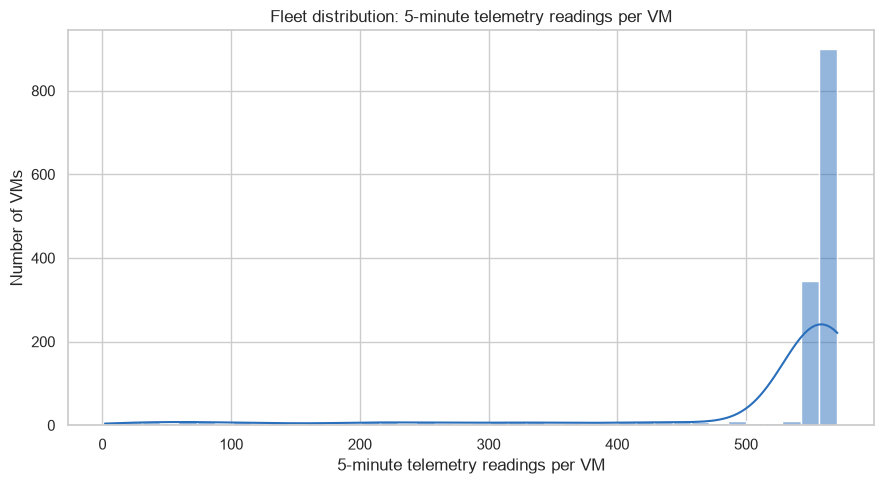

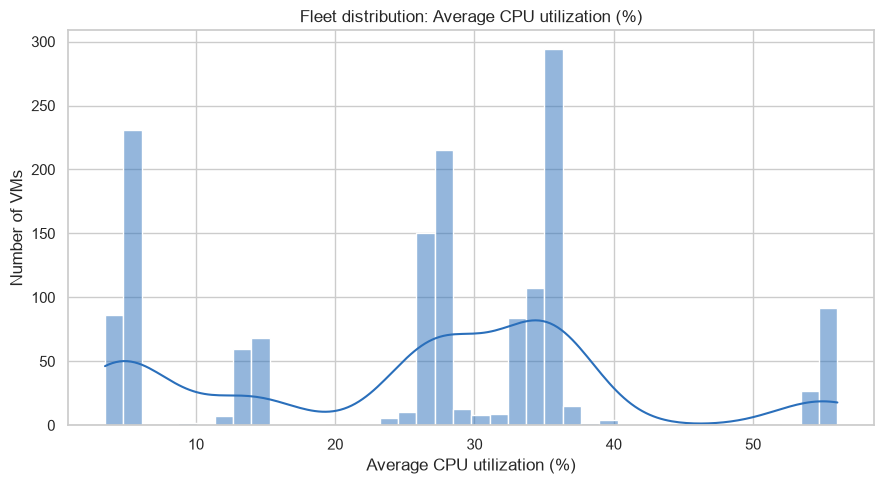

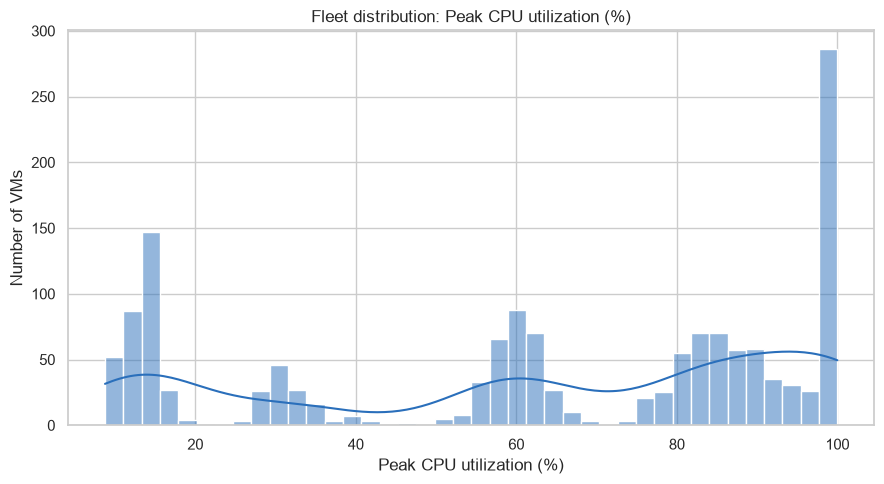

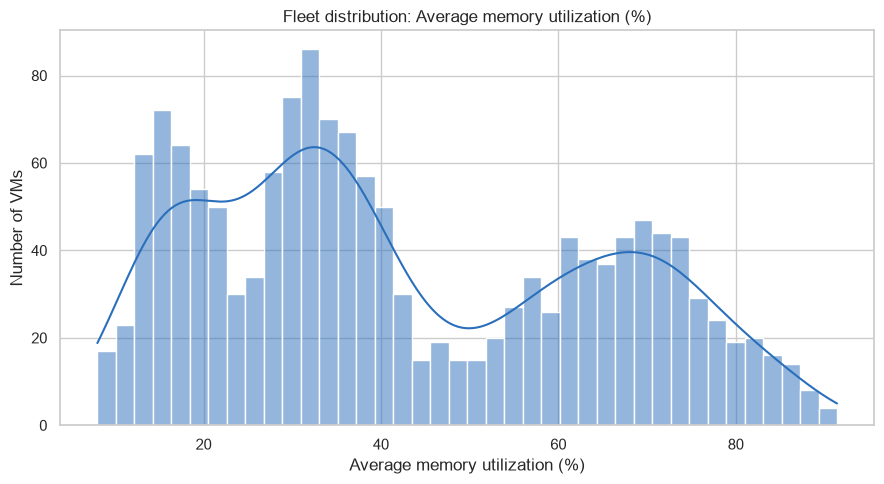

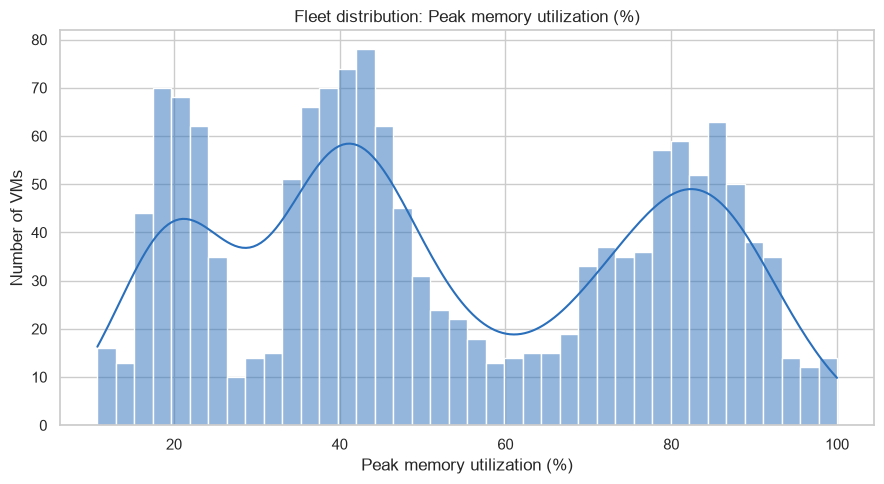

Saved 5 histogram figures to: c:\Users\kdank\OneDrive\Desktop\VM_Segmentation_Project\outputs\figures


,vm_id,telemetry_readings,average_cpu_utilization_pct,peak_cpu_utilization_pct,average_memory_utilization_pct,peak_memory_utilization_pct
0,vm_00000,555,36.713441,64.77,37.984649,47.27
1,vm_00001,557,56.013196,100.00,47.486643,61.47
2,vm_00002,557,14.043124,31.77,75.836643,82.02
3,vm_00003,15,33.130000,52.84,35.998000,42.98
4,vm_00004,555,27.124486,88.32,60.805441,78.39


In [24]:
FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Aggregate 5-minute readings to one behavioural summary for each VM.
per_vm_utilization_summary = (
    vm_utilization
    .groupby('vm_id', as_index=False)
    .agg(
        telemetry_readings=('timestamp', 'size'),
        average_cpu_utilization_pct=('avg_cpu_5min', 'mean'),
        peak_cpu_utilization_pct=('max_cpu_5min', 'max'),
        average_memory_utilization_pct=('avg_memory_5min', 'mean'),
        peak_memory_utilization_pct=('max_memory_5min', 'max'),
    )
)

usage_metrics = [
    'average_cpu_utilization_pct',
    'peak_cpu_utilization_pct',
    'average_memory_utilization_pct',
    'peak_memory_utilization_pct',
]
summary_metrics = ['telemetry_readings', *usage_metrics]

# Quantify fleet-wide spread, central tendency, and tails for every per-VM metric.
fleet_utilization_descriptive_statistics = (
    per_vm_utilization_summary[summary_metrics]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99])
    .T
)

print(f'Per-VM utilization summary: {per_vm_utilization_summary.shape[0]:,} VMs')
display(fleet_utilization_descriptive_statistics)

metric_labels = {
    'telemetry_readings': '5-minute telemetry readings per VM',
    'average_cpu_utilization_pct': 'Average CPU utilization (%)',
    'peak_cpu_utilization_pct': 'Peak CPU utilization (%)',
    'average_memory_utilization_pct': 'Average memory utilization (%)',
    'peak_memory_utilization_pct': 'Peak memory utilization (%)',
}

# Save a separate, readable histogram for every key per-VM metric.
for metric in summary_metrics:
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.histplot(
        data=per_vm_utilization_summary,
        x=metric,
        bins=40,
        kde=True,
        color='#2a6fbb',
        ax=ax,
    )
    ax.set_title(f'Fleet distribution: {metric_labels[metric]}')
    ax.set_xlabel(metric_labels[metric])
    ax.set_ylabel('Number of VMs')
    fig.tight_layout()
    figure_path = FIGURES_DIR / f'{metric}_histogram.png'
    fig.savefig(figure_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

print(f'Saved {len(summary_metrics)} histogram figures to: {FIGURES_DIR}')
per_vm_utilization_summary.head()

## Utilization, provisioned-resource, and coverage relationships

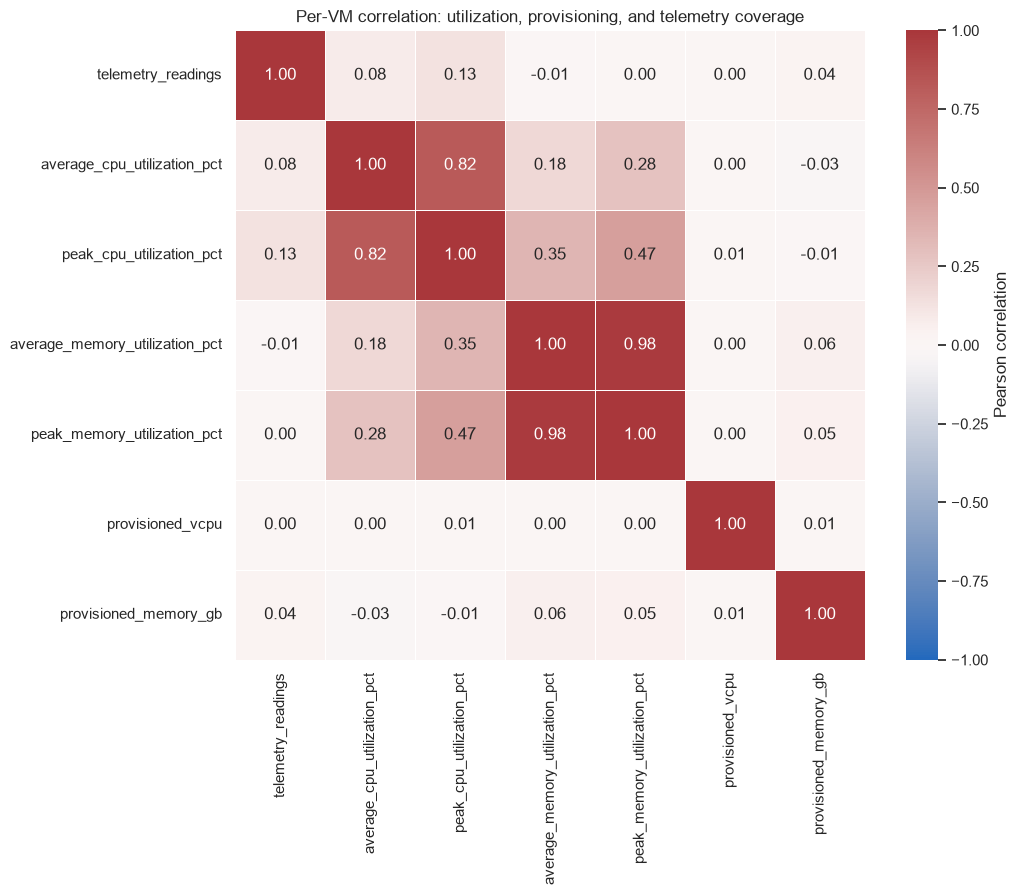

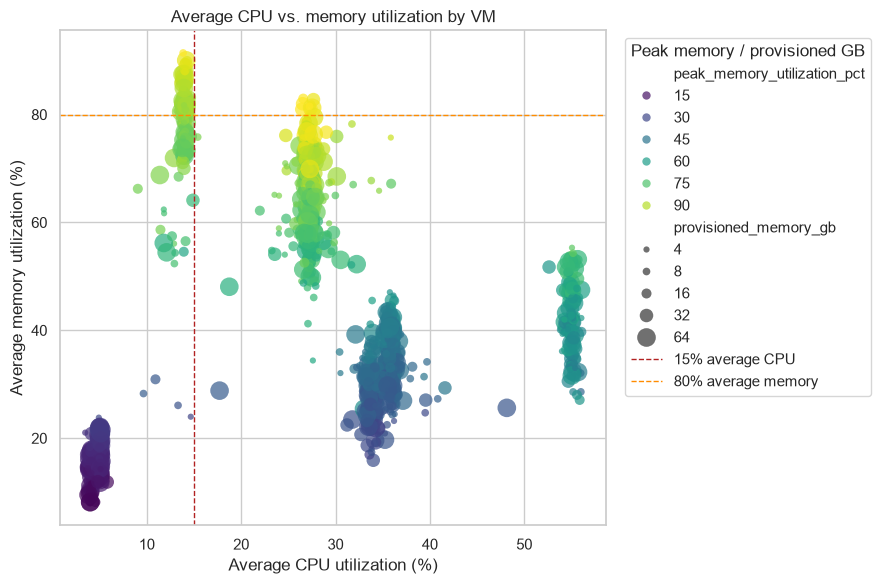

Saved correlation heatmap to: c:\Users\kdank\OneDrive\Desktop\VM_Segmentation_Project\outputs\figures\per_vm_correlation_heatmap.png
Saved CPU-vs-memory scatter plot to: c:\Users\kdank\OneDrive\Desktop\VM_Segmentation_Project\outputs\figures\average_cpu_vs_memory_scatter.png


,telemetry_readings,average_cpu_utilization_pct,peak_cpu_utilization_pct,average_memory_utilization_pct,peak_memory_utilization_pct,provisioned_vcpu,provisioned_memory_gb
telemetry_readings,1.000000,0.082703,0.125264,-0.009472,0.002497,0.003242,0.036785
average_cpu_utilization_pct,0.082703,1.000000,0.821088,0.178512,0.283948,0.001972,-0.025028
peak_cpu_utilization_pct,0.125264,0.821088,1.000000,0.348137,0.468617,0.013796,-0.006942
average_memory_utilization_pct,-0.009472,0.178512,0.348137,1.000000,0.979215,0.001556,0.055673
peak_memory_utilization_pct,0.002497,0.283948,0.468617,0.979215,1.000000,0.001387,0.049937
provisioned_vcpu,0.003242,0.001972,0.013796,0.001556,0.001387,1.000000,0.013962
provisioned_memory_gb,0.036785,-0.025028,-0.006942,0.055673,0.049937,0.013962,1.000000


In [25]:
# Load the master table when it was created in a prior notebook session.
if 'vm_master_table' not in globals():
    vm_master_table = pd.read_csv(OUTPUT_DIR / 'vm_master_table.csv')

correlation_columns = [
    'telemetry_readings',
    'average_cpu_utilization_pct',
    'peak_cpu_utilization_pct',
    'average_memory_utilization_pct',
    'peak_memory_utilization_pct',
    'provisioned_vcpu',
    'provisioned_memory_gb',
]

per_vm_analysis_table = per_vm_utilization_summary.merge(
    vm_master_table[['vm_id', 'provisioned_vcpu', 'provisioned_memory_gb']],
    on='vm_id',
    how='left',
    validate='one_to_one',
)

assert per_vm_analysis_table[['provisioned_vcpu', 'provisioned_memory_gb']].notna().all().all(), (
    'Provisioned-resource values are missing after the VM master-table join.'
)
correlation_matrix = per_vm_analysis_table[correlation_columns].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    correlation_matrix, annot=True, fmt='.2f', cmap='vlag', center=0,
    vmin=-1, vmax=1, square=True, linewidths=0.5,
    cbar_kws={'label': 'Pearson correlation'}, ax=ax,
)
ax.set_title('Per-VM correlation: utilization, provisioning, and telemetry coverage')
fig.tight_layout()
correlation_figure_path = FIGURES_DIR / 'per_vm_correlation_heatmap.png'
fig.savefig(correlation_figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=per_vm_analysis_table,
    x='average_cpu_utilization_pct',
    y='average_memory_utilization_pct',
    hue='peak_memory_utilization_pct',
    palette='viridis',
    size='provisioned_memory_gb',
    sizes=(20, 180),
    alpha=0.70,
    edgecolor='none',
    ax=ax,
)
ax.axvline(15, color='firebrick', linestyle='--', linewidth=1, label='15% average CPU')
ax.axhline(80, color='darkorange', linestyle='--', linewidth=1, label='80% average memory')
ax.set_title('Average CPU vs. memory utilization by VM')
ax.set_xlabel('Average CPU utilization (%)')
ax.set_ylabel('Average memory utilization (%)')
ax.legend(title='Peak memory / provisioned GB', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
scatter_figure_path = FIGURES_DIR / 'average_cpu_vs_memory_scatter.png'
fig.savefig(scatter_figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)

print(f'Saved correlation heatmap to: {correlation_figure_path}')
print(f'Saved CPU-vs-memory scatter plot to: {scatter_figure_path}')
display(correlation_matrix)

## Business-hours CPU behaviour

Timestamps are recorded in UTC. Adjust the configurable hour range below if the business-hours definition should use another timezone.

Business-hours-driven VMs: 621 of 1,499


is_business_hour,vm_id,off_hours_average_cpu_pct,business_hours_average_cpu_pct,cpu_uplift_ratio,cpu_uplift_pct_points,is_business_hours_driven
270,vm_00270,10.734438,65.784766,6.128385,55.050328,True
653,vm_00653,11.588809,65.990985,5.694372,54.402177,True
827,vm_00827,12.034635,66.256871,5.505516,54.222236,True
567,vm_00567,19.746901,73.867805,3.740729,54.120903,True
1401,vm_01401,12.932754,66.615970,5.150950,53.683217,True
1068,vm_01068,12.387216,66.020776,5.329751,53.633559,True
601,vm_00601,12.214492,65.798889,5.386952,53.584397,True
1414,vm_01414,11.849136,65.389828,5.518531,53.540693,True
1218,vm_01218,11.662362,64.950129,5.569209,53.287767,True
568,vm_00568,11.890369,65.175470,5.481366,53.285101,True


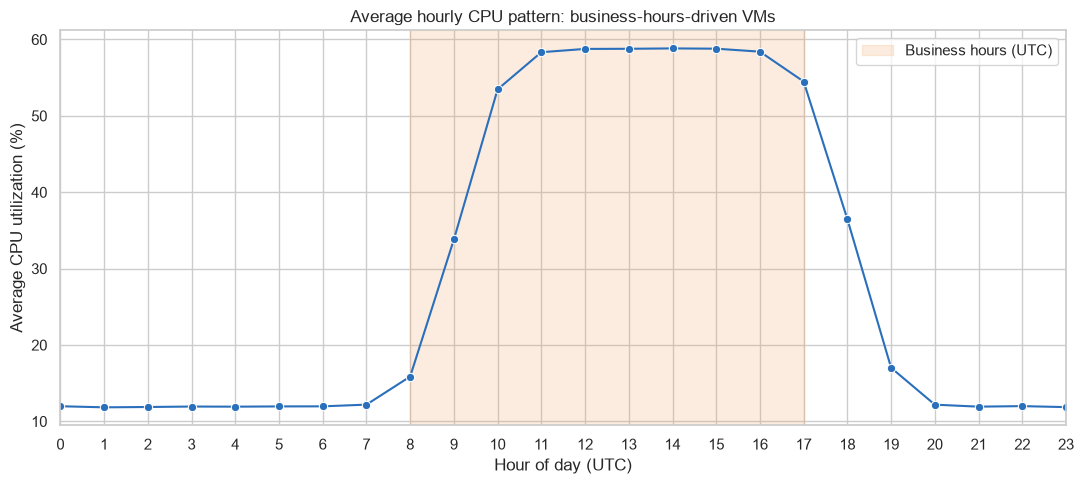

Saved business-hours CPU figure to: c:\Users\kdank\OneDrive\Desktop\VM_Segmentation_Project\outputs\figures\business_hours_driven_vm_hourly_cpu.png


In [26]:
# UTC business-hours definition; the source timestamps are stored in UTC.
BUSINESS_HOUR_START_UTC = 8   # inclusive
BUSINESS_HOUR_END_UTC = 18    # exclusive
CPU_UPLIFT_RATIO_THRESHOLD = 1.5
CPU_UPLIFT_ABSOLUTE_THRESHOLD_PCT = 5.0

FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

utilization_with_hour = vm_utilization.assign(
    timestamp_utc=pd.to_datetime(vm_utilization['timestamp'], unit='s', utc=True),
)
utilization_with_hour['hour_of_day_utc'] = utilization_with_hour['timestamp_utc'].dt.hour
utilization_with_hour['is_business_hour'] = utilization_with_hour['hour_of_day_utc'].between(
    BUSINESS_HOUR_START_UTC, BUSINESS_HOUR_END_UTC - 1
)

# Compare each VM's mean CPU in business hours with its mean CPU in off-hours.
business_hours_cpu_summary = (
    utilization_with_hour
    .groupby(['vm_id', 'is_business_hour'])['avg_cpu_5min']
    .mean()
    .unstack('is_business_hour')
    .rename(columns={False: 'off_hours_average_cpu_pct', True: 'business_hours_average_cpu_pct'})
    .reindex(columns=['off_hours_average_cpu_pct', 'business_hours_average_cpu_pct'])
    .reset_index()
)
business_hours_cpu_summary['cpu_uplift_ratio'] = (
    business_hours_cpu_summary['business_hours_average_cpu_pct']
    / business_hours_cpu_summary['off_hours_average_cpu_pct'].replace(0, np.nan)
)
business_hours_cpu_summary['cpu_uplift_pct_points'] = (
    business_hours_cpu_summary['business_hours_average_cpu_pct']
    - business_hours_cpu_summary['off_hours_average_cpu_pct']
)
business_hours_cpu_summary['is_business_hours_driven'] = (
    business_hours_cpu_summary['cpu_uplift_ratio'].ge(CPU_UPLIFT_RATIO_THRESHOLD)
    & business_hours_cpu_summary['cpu_uplift_pct_points'].ge(CPU_UPLIFT_ABSOLUTE_THRESHOLD_PCT)
)

business_hours_driven_vms = business_hours_cpu_summary.loc[
    business_hours_cpu_summary['is_business_hours_driven'], 'vm_id'
]
print(f'Business-hours-driven VMs: {business_hours_driven_vms.nunique():,} of {business_hours_cpu_summary.shape[0]:,}')
display(business_hours_cpu_summary.sort_values('cpu_uplift_pct_points', ascending=False).head(10))

# Give each flagged VM equal weight before deriving the group's average hourly pattern.
flagged_vm_hourly_cpu = (
    utilization_with_hour.loc[utilization_with_hour['vm_id'].isin(business_hours_driven_vms)]
    .groupby(['vm_id', 'hour_of_day_utc'], as_index=False)['avg_cpu_5min']
    .mean()
)
average_hourly_cpu_pattern = (
    flagged_vm_hourly_cpu
    .groupby('hour_of_day_utc', as_index=False)['avg_cpu_5min']
    .mean()
)

fig, ax = plt.subplots(figsize=(11, 5))
if average_hourly_cpu_pattern.empty:
    ax.text(0.5, 0.5, 'No VMs met the business-hours-driven criteria.', ha='center', va='center', transform=ax.transAxes)
else:
    sns.lineplot(data=average_hourly_cpu_pattern, x='hour_of_day_utc', y='avg_cpu_5min', marker='o', color='#2a6fbb', ax=ax)
    ax.axvspan(BUSINESS_HOUR_START_UTC, BUSINESS_HOUR_END_UTC - 1, color='#f4a261', alpha=0.20, label='Business hours (UTC)')
    ax.legend()
ax.set_title('Average hourly CPU pattern: business-hours-driven VMs')
ax.set_xlabel('Hour of day (UTC)')
ax.set_ylabel('Average CPU utilization (%)')
ax.set_xticks(range(24))
ax.set_xlim(0, 23)
fig.tight_layout()
business_hours_figure_path = FIGURES_DIR / 'business_hours_driven_vm_hourly_cpu.png'
fig.savefig(business_hours_figure_path, dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'Saved business-hours CPU figure to: {business_hours_figure_path}')

## Sparse-telemetry exclusion

Use an IQR-derived lower fence, rather than a fixed reading-count threshold, to exclude VMs that lack enough observation coverage for a dependable behavioural fingerprint.

In [27]:
from contextlib import redirect_stdout
from io import StringIO

SPARSE_VM_REPORT_PATH = OUTPUT_DIR / 'sparse_vm_report.txt'

# The master table includes every metadata VM, including VMs with zero telemetry.
if 'vm_master_table' not in globals():
    vm_master_table = pd.read_csv(OUTPUT_DIR / 'vm_master_table.csv')

telemetry_coverage_by_vm = (
    vm_master_table[['vm_id']]
    .merge(
        vm_utilization.groupby('vm_id').size().rename('telemetry_readings'),
        left_on='vm_id',
        right_index=True,
        how='left',
        validate='one_to_one',
    )
    .assign(telemetry_readings=lambda frame: frame['telemetry_readings'].fillna(0).astype(int))
)

# Derive the sparse-coverage threshold from the lower IQR fence of the observed fleet.
positive_reading_counts = telemetry_coverage_by_vm.loc[
    telemetry_coverage_by_vm['telemetry_readings'].gt(0), 'telemetry_readings'
]
q1 = positive_reading_counts.quantile(0.25)
q3 = positive_reading_counts.quantile(0.75)
iqr = q3 - q1
lower_iqr_fence = max(0, q1 - 1.5 * iqr)

telemetry_coverage_by_vm['drop_reason'] = np.select(
    [
        telemetry_coverage_by_vm['telemetry_readings'].eq(0),
        telemetry_coverage_by_vm['telemetry_readings'].lt(lower_iqr_fence),
    ],
    [
        'No utilization readings; no behavioural fingerprint can be calculated.',
        'Reading count falls below the data-derived lower IQR fence.',
    ],
    default='Retain: reading count is within the normal fleet coverage range.',
)
telemetry_coverage_by_vm['drop_for_sparse_telemetry'] = (
    telemetry_coverage_by_vm['telemetry_readings'].eq(0)
    | telemetry_coverage_by_vm['telemetry_readings'].lt(lower_iqr_fence)
)
sparse_vm_ids = telemetry_coverage_by_vm.loc[
    telemetry_coverage_by_vm['drop_for_sparse_telemetry'], 'vm_id'
]

# These are the analysis-ready tables; the original loaded tables remain unchanged.
vm_utilization_clean = vm_utilization.loc[~vm_utilization['vm_id'].isin(sparse_vm_ids)].copy()
vm_master_table_clean = vm_master_table.loc[~vm_master_table['vm_id'].isin(sparse_vm_ids)].copy()

assert vm_master_table_clean['vm_id'].is_unique
assert not vm_utilization_clean['vm_id'].isin(sparse_vm_ids).any()
assert not vm_master_table_clean['vm_id'].isin(sparse_vm_ids).any()

sparse_report_buffer = StringIO()
with redirect_stdout(sparse_report_buffer):
    print('Sparse VM telemetry report')
    print('=' * 80)
    print(f'VMs assessed: {len(telemetry_coverage_by_vm):,}')
    print(f'Positive-coverage Q1: {q1:.2f} readings')
    print(f'Positive-coverage Q3: {q3:.2f} readings')
    print(f'IQR: {iqr:.2f} readings')
    print(f'Lower IQR fence: {lower_iqr_fence:.2f} readings')
    print(f'VMs dropped: {len(sparse_vm_ids):,}')
    print(f'  - No readings: {(telemetry_coverage_by_vm["telemetry_readings"] == 0).sum():,}')
    print(f'  - Below lower IQR fence with readings: {((telemetry_coverage_by_vm["telemetry_readings"] > 0) & (telemetry_coverage_by_vm["telemetry_readings"] < lower_iqr_fence)).sum():,}')
    print(f'VM master rows retained: {len(vm_master_table_clean):,}')
    print(f'Utilization readings retained: {len(vm_utilization_clean):,}')
    print('\nDropped VMs:')
    print(telemetry_coverage_by_vm.loc[telemetry_coverage_by_vm['drop_for_sparse_telemetry']].sort_values('telemetry_readings').to_string(index=False))

sparse_vm_report = sparse_report_buffer.getvalue()
print(sparse_vm_report)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SPARSE_VM_REPORT_PATH.write_text(sparse_vm_report, encoding='utf-8')
print(f'Sparse-telemetry report saved to: {SPARSE_VM_REPORT_PATH}')

Sparse VM telemetry report
VMs assessed: 1,500
Positive-coverage Q1: 553.00 readings
Positive-coverage Q3: 561.00 readings
IQR: 8.00 readings
Lower IQR fence: 541.00 readings
VMs dropped: 253
  - No readings: 1
  - Below lower IQR fence with readings: 252
VM master rows retained: 1,247
Utilization readings retained: 696,689

Dropped VMs:
   vm_id  telemetry_readings                                                            drop_reason  drop_for_sparse_telemetry
vm_01497                   0 No utilization readings; no behavioural fingerprint can be calculated.                       True
vm_01196                   2            Reading count falls below the data-derived lower IQR fence.                       True
vm_01329                   3            Reading count falls below the data-derived lower IQR fence.                       True
vm_00285                   6            Reading count falls below the data-derived lower IQR fence.                       True
vm_01207                 

## Per-VM behavioural feature table

Collapse the cleaned 5-minute telemetry into clustering-ready behavioural features. Workload type and provisioned capacity are retained only as profiling fields.

In [28]:
VM_FEATURES_PATH = OUTPUT_DIR / 'vm_features.csv'
IDLE_THRESHOLD_PCT = 5.0
SATURATION_THRESHOLD_PCT = 90.0
BURSTINESS_CAP_QUANTILE = 0.99
business_hour_start = globals().get('BUSINESS_HOUR_START_UTC', 8)
business_hour_end = globals().get('BUSINESS_HOUR_END_UTC', 18)

if 'vm_utilization_clean' not in globals() or 'vm_master_table_clean' not in globals():
    raise RuntimeError('Run the sparse-telemetry exclusion cell before building clustering features.')

feature_source = vm_utilization_clean.assign(
    timestamp_utc=pd.to_datetime(vm_utilization_clean['timestamp'], unit='s', utc=True),
)
feature_source['hour_of_day_utc'] = feature_source['timestamp_utc'].dt.hour
feature_source['is_business_hour'] = feature_source['hour_of_day_utc'].between(
    business_hour_start, business_hour_end - 1
)

# Typical use, peak demand, variability, idle time, and saturation frequency for both resources.
vm_behavioral_features = (
    feature_source
    .groupby('vm_id', as_index=False)
    .agg(
        telemetry_readings=('timestamp', 'size'),
        cpu_typical_utilization_pct=('avg_cpu_5min', 'mean'),
        cpu_peak_utilization_pct=('max_cpu_5min', 'max'),
        cpu_utilization_std_pct=('avg_cpu_5min', 'std'),
        cpu_idle_fraction=('avg_cpu_5min', lambda values: (values < IDLE_THRESHOLD_PCT).mean()),
        cpu_saturation_fraction=('max_cpu_5min', lambda values: (values >= SATURATION_THRESHOLD_PCT).mean()),
        memory_typical_utilization_pct=('avg_memory_5min', 'mean'),
        memory_peak_utilization_pct=('max_memory_5min', 'max'),
        memory_utilization_std_pct=('avg_memory_5min', 'std'),
        memory_idle_fraction=('avg_memory_5min', lambda values: (values < IDLE_THRESHOLD_PCT).mean()),
        memory_saturation_fraction=('max_memory_5min', lambda values: (values >= SATURATION_THRESHOLD_PCT).mean()),
    )
)

# Business-hours uplift is expressed in percentage points to avoid unstable ratios near zero.
business_hours_cpu = (
    feature_source
    .groupby(['vm_id', 'is_business_hour'])['avg_cpu_5min']
    .mean()
    .unstack('is_business_hour')
    .rename(columns={False: 'off_hours_cpu_pct', True: 'business_hours_cpu_pct'})
    .reindex(columns=['off_hours_cpu_pct', 'business_hours_cpu_pct'])
    .reset_index()
)
business_hours_cpu['business_hours_cpu_uplift_pct_points'] = (
    business_hours_cpu['business_hours_cpu_pct'] - business_hours_cpu['off_hours_cpu_pct']
)

vm_behavioral_features = vm_behavioral_features.merge(
    business_hours_cpu[['vm_id', 'business_hours_cpu_uplift_pct_points']],
    on='vm_id',
    how='left',
    validate='one_to_one',
)

# Peak-to-typical CPU ratio captures burstiness; cap its upper tail before distance-based clustering.
vm_behavioral_features['cpu_burstiness_raw'] = (
    vm_behavioral_features['cpu_peak_utilization_pct']
    / vm_behavioral_features['cpu_typical_utilization_pct'].clip(lower=0.1)
)
cpu_burstiness_cap = vm_behavioral_features['cpu_burstiness_raw'].quantile(BURSTINESS_CAP_QUANTILE)
vm_behavioral_features['cpu_burstiness_capped'] = vm_behavioral_features['cpu_burstiness_raw'].clip(upper=cpu_burstiness_cap)

profiling_columns = [
    'vm_id', 'vm_category', 'core_count_bucket', 'memory_bucket',
    'provisioned_vcpu', 'provisioned_memory_gb',
]
vm_features = vm_master_table_clean[profiling_columns].merge(
    vm_behavioral_features,
    on='vm_id',
    how='inner',
    validate='one_to_one',
)

# These are the only columns intended as input to the clustering model.
clustering_feature_columns = [
    'cpu_typical_utilization_pct', 'cpu_peak_utilization_pct', 'cpu_utilization_std_pct',
    'cpu_idle_fraction', 'cpu_saturation_fraction',
    'memory_typical_utilization_pct', 'memory_peak_utilization_pct', 'memory_utilization_std_pct',
    'memory_idle_fraction', 'memory_saturation_fraction',
    'cpu_burstiness_capped', 'business_hours_cpu_uplift_pct_points',
]

assert vm_features['vm_id'].is_unique
assert vm_features[clustering_feature_columns].notna().all().all(), 'A clustering feature is missing.'
assert not {'vm_category', 'provisioned_vcpu', 'provisioned_memory_gb'} & set(clustering_feature_columns)

vm_features.to_csv(VM_FEATURES_PATH, index=False)
print(f'Feature table: {vm_features.shape[0]:,} VMs × {vm_features.shape[1]} columns')
print(f'CPU burstiness cap (P{BURSTINESS_CAP_QUANTILE:.0%}): {cpu_burstiness_cap:.2f}')
print(f'Clustering features ({len(clustering_feature_columns)}): {clustering_feature_columns}')
print('Profiling-only fields excluded from clustering: vm_category, provisioned_vcpu, provisioned_memory_gb')
print(f'Saved to: {VM_FEATURES_PATH}')
vm_features.head()

Feature table: 1,247 VMs × 20 columns
CPU burstiness cap (P99%): 3.53
Clustering features (12): ['cpu_typical_utilization_pct', 'cpu_peak_utilization_pct', 'cpu_utilization_std_pct', 'cpu_idle_fraction', 'cpu_saturation_fraction', 'memory_typical_utilization_pct', 'memory_peak_utilization_pct', 'memory_utilization_std_pct', 'memory_idle_fraction', 'memory_saturation_fraction', 'cpu_burstiness_capped', 'business_hours_cpu_uplift_pct_points']
Profiling-only fields excluded from clustering: vm_category, provisioned_vcpu, provisioned_memory_gb
Saved to: c:\Users\kdank\OneDrive\Desktop\VM_Segmentation_Project\outputs\vm_features.csv


,vm_id,vm_category,core_count_bucket,memory_bucket,provisioned_vcpu,provisioned_memory_gb,telemetry_readings,cpu_typical_utilization_pct,cpu_peak_utilization_pct,cpu_utilization_std_pct,cpu_idle_fraction,cpu_saturation_fraction,memory_typical_utilization_pct,memory_peak_utilization_pct,memory_utilization_std_pct,memory_idle_fraction,memory_saturation_fraction,business_hours_cpu_uplift_pct_points,cpu_burstiness_raw,cpu_burstiness_capped
0,vm_00000,Interactive,large_8_16,xxlarge_64_128,8,64,555,36.713441,64.77,6.263248,0.000000,0.000000,37.984649,47.27,1.078886,0.0,0.0,2.371497,1.764204,1.764204
1,vm_00001,Delay-Insensitive,xlarge_16_32,xxlarge_64_128,16,64,557,56.013196,100.00,10.905366,0.000000,0.057451,47.486643,61.47,2.336216,0.0,0.0,1.448985,1.785294,1.785294
2,vm_00002,Delay-Insensitive,large_8_16,medium_8_16,8,8,557,14.043124,31.77,3.892891,0.008977,0.000000,75.836643,82.02,0.864043,0.0,0.0,-0.345105,2.262317,2.262317
3,vm_00004,Interactive,large_8_16,small_4_8,8,4,555,27.124486,88.32,19.586019,0.111712,0.000000,60.805441,78.39,3.641546,0.0,0.0,30.754163,3.256099,3.256099
4,vm_00005,Interactive,medium_4_8,xlarge_32_64,4,32,560,35.706089,63.89,6.302991,0.000000,0.000000,32.476143,37.73,1.818341,0.0,0.0,2.576064,1.789331,1.789331


## Feature scaling and t-SNE structure check

Compare several t-SNE perplexities with the same random seed before treating apparent separation as stable structure.

In [ ]:
from sklearn.manifold import TSNE
import plotly.express as px

if 'vm_features' not in globals():
    vm_features = pd.read_csv(OUTPUT_DIR / 'vm_features.csv')

if 'clustering_feature_columns' not in globals():
    clustering_feature_columns = [
        'cpu_typical_utilization_pct', 'cpu_peak_utilization_pct', 'cpu_utilization_std_pct',
        'cpu_idle_fraction', 'cpu_saturation_fraction',
        'memory_typical_utilization_pct', 'memory_peak_utilization_pct', 'memory_utilization_std_pct',
        'memory_idle_fraction', 'memory_saturation_fraction',
        'cpu_burstiness_capped', 'business_hours_cpu_uplift_pct_points',
    ]

FIGURES_DIR = OUTPUT_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Remove zero-variance behavioural features: they contain no separation signal and cannot have unit variance after scaling.
feature_variances = vm_features[clustering_feature_columns].var(ddof=0)
zero_variance_features = feature_variances.index[feature_variances.eq(0)].tolist()
clustering_feature_columns = [
    feature for feature in clustering_feature_columns if feature not in zero_variance_features
]
print(f"Excluded zero-variance features: {zero_variance_features or 'None'}")

# Scale only behavioural features; workload type and provisioned capacity remain profiling fields.
feature_scaler = StandardScaler()
standardized_features = feature_scaler.fit_transform(vm_features[clustering_feature_columns])
standardized_feature_table = pd.DataFrame(standardized_features, columns=clustering_feature_columns, index=vm_features['vm_id'])
scaling_check = pd.DataFrame({'mean_after_scaling': standardized_feature_table.mean(), 'std_after_scaling_ddof0': standardized_feature_table.std(ddof=0)})
display(scaling_check.round(6))
assert np.allclose(scaling_check['mean_after_scaling'], 0, atol=1e-10)
assert np.allclose(scaling_check['std_after_scaling_ddof0'], 1, atol=1e-10)
print('Scaling check passed: every clustering feature has mean ≈ 0 and standard deviation ≈ 1.')

PERPLEXITY_VALUES = [10, 30, 50]
TSNE_RANDOM_STATE = RANDOM_STATE
assert max(PERPLEXITY_VALUES) < len(vm_features)
tsne_embeddings_2d = {
    perplexity: TSNE(n_components=2, perplexity=perplexity, init='pca', learning_rate='auto', max_iter=1000, random_state=TSNE_RANDOM_STATE).fit_transform(standardized_features)
    for perplexity in PERPLEXITY_VALUES
}

fig, axes = plt.subplots(1, len(PERPLEXITY_VALUES), figsize=(18, 5.5))
for axis, perplexity in zip(axes, PERPLEXITY_VALUES):
    embedding_table = pd.DataFrame(tsne_embeddings_2d[perplexity], columns=['tsne_1', 'tsne_2']).join(vm_features[['vm_category']])
    sns.scatterplot(data=embedding_table, x='tsne_1', y='tsne_2', hue='vm_category', palette='Set2', s=18, alpha=0.7, linewidth=0, legend=(perplexity == PERPLEXITY_VALUES[-1]), ax=axis)
    axis.set(title=f't-SNE, perplexity = {perplexity}', xlabel='t-SNE component 1', ylabel='t-SNE component 2')
fig.suptitle('Stability check: t-SNE maps across perplexity settings', y=1.02)
fig.tight_layout()
tsne_comparison_path = FIGURES_DIR / 'tsne_2d_perplexity_comparison.png'
fig.savefig(tsne_comparison_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

# Perplexity 30 is the balanced setting selected from the comparison.
CHOSEN_PERPLEXITY = 30
tsne_embedding_3d = TSNE(n_components=3, perplexity=CHOSEN_PERPLEXITY, init='pca', learning_rate='auto', max_iter=1000, random_state=TSNE_RANDOM_STATE).fit_transform(standardized_features)
tsne_3d_table = vm_features[['vm_id', 'vm_category', 'provisioned_vcpu', 'provisioned_memory_gb']].copy()
tsne_3d_table[['tsne_1', 'tsne_2', 'tsne_3']] = tsne_embedding_3d
tsne_3d_figure = px.scatter_3d(tsne_3d_table, x='tsne_1', y='tsne_2', z='tsne_3', color='vm_category', hover_data=['vm_id', 'provisioned_vcpu', 'provisioned_memory_gb'], opacity=0.72, title=f'Interactive 3D t-SNE projection (perplexity = {CHOSEN_PERPLEXITY})')
tsne_3d_figure.update_traces(marker={'size': 3})
tsne_3d_html_path = FIGURES_DIR / f'tsne_3d_perplexity_{CHOSEN_PERPLEXITY}.html'
# Save as self-contained HTML instead of rendering Plotly inline, avoiding notebook MIME-renderer compatibility errors.
tsne_3d_figure.write_html(tsne_3d_html_path, include_plotlyjs=True, full_html=True)

print(f'Saved 2D t-SNE comparison to: {tsne_comparison_path}')
print(f'Saved interactive 3D t-SNE plot to: {tsne_3d_html_path}')

## K-Means cluster-count selection

### Selected model: 7 clusters

The elbow curve slows materially after seven groups, while the silhouette score peaks at **0.672** for `k=7` (versus 0.657 at `k=6` and 0.622 at `k=8`). Seven groups preserve operationally distinct behaviours, including a small high-memory-saturation group alongside lower-utilization, business-hours-bursty, CPU-intensive, and memory-heavy groups—segments that can warrant different rightsizing actions.

No lower `k` scored better statistically: every value from 2 through 6 has a lower silhouette score than `k=7`. Therefore, no lower-scoring model was rejected despite a better statistical score. In particular, `k=6` was rejected because it both scores slightly worse and risks combining behavioural groups that should be profiled and actioned separately. `k=8` and above were rejected because silhouette declines after seven while WCSS improvements become incremental, indicating over-segmentation rather than a clearer action taxonomy.

In [ ]:
from sklearn.metrics import silhouette_score

if 'standardized_features' not in globals():
    raise RuntimeError('Run the feature scaling and t-SNE cell before evaluating K-Means.')

K_VALUES = list(range(2, 11))
kmeans_diagnostics = []
for k in K_VALUES:
    candidate_model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=25)
    candidate_labels = candidate_model.fit_predict(standardized_features)
    kmeans_diagnostics.append({
        'k': k,
        'wcss': candidate_model.inertia_,
        'silhouette_score': silhouette_score(standardized_features, candidate_labels),
    })

kmeans_diagnostics = pd.DataFrame(kmeans_diagnostics)
display(kmeans_diagnostics.round(4))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kmeans_diagnostics['k'], kmeans_diagnostics['wcss'], marker='o', color='#2a6fbb')
ax.axvline(7, color='firebrick', linestyle='--', label='Selected k = 7')
ax.set(title='K-Means elbow curve', xlabel='Number of clusters (k)', ylabel='WCSS / inertia')
ax.set_xticks(K_VALUES)
ax.legend()
fig.tight_layout()
wcss_figure_path = FIGURES_DIR / 'kmeans_wcss_elbow_curve.png'
fig.savefig(wcss_figure_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kmeans_diagnostics['k'], kmeans_diagnostics['silhouette_score'], marker='o', color='#457b9d')
ax.axvline(7, color='firebrick', linestyle='--', label='Selected k = 7')
ax.set(title='K-Means silhouette-score curve', xlabel='Number of clusters (k)', ylabel='Mean silhouette score')
ax.set_xticks(K_VALUES)
ax.legend()
fig.tight_layout()
silhouette_figure_path = FIGURES_DIR / 'kmeans_silhouette_score_curve.png'
fig.savefig(silhouette_figure_path, dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

CHOSEN_K = 7
final_kmeans_model = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init=25)
final_cluster_labels = final_kmeans_model.fit_predict(standardized_features)

# Attach labels to the feature table and persist the enriched version.
vm_features = vm_features.copy()
vm_features['cluster_label'] = final_cluster_labels
VM_FEATURES_PATH = OUTPUT_DIR / 'vm_features.csv'
vm_features.to_csv(VM_FEATURES_PATH, index=False)

# Attach the same labels to all 2D t-SNE maps and the chosen 3D t-SNE projection.
if 'tsne_embeddings_2d' not in globals() or 'tsne_3d_table' not in globals():
    raise RuntimeError('Run the t-SNE cell before this cell so cluster labels can be attached to both projections.')

tsne_2d_clustered = {}
for perplexity, embedding in tsne_embeddings_2d.items():
    tsne_2d_clustered[perplexity] = pd.DataFrame(embedding, columns=['tsne_1', 'tsne_2'])
    tsne_2d_clustered[perplexity]['vm_id'] = vm_features['vm_id'].to_numpy()
    tsne_2d_clustered[perplexity]['cluster_label'] = final_cluster_labels

tsne_3d_table = tsne_3d_table.copy()
tsne_3d_table['cluster_label'] = final_cluster_labels

print(f'Final K-Means model trained with k={CHOSEN_K}.')
print(f'Cluster sizes: {vm_features["cluster_label"].value_counts().sort_index().to_dict()}')
print(f'Saved elbow curve to: {wcss_figure_path}')
print(f'Saved silhouette curve to: {silhouette_figure_path}')
print(f'Feature table with cluster labels saved to: {VM_FEATURES_PATH}')